In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from openbabel import pybel
from math import log10
from periodictable import periodicTable
fullPeriodicTable = periodicTable().tableDict
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']

In [2]:
def load_data(datapath: str, filename: str, *, sep = ',', header=0) -> pd.DataFrame:
    data = pd.read_csv(f'{datapath}{filename}', sep=sep, header=header)
    return data

def parse_atom_nums(smi: str) -> np.array:
    atomNums = [atom.atomicnum for atom in pybel.readstring('smi', smi)]
    return np.array(atomNums)

def toAtomNum(smiles: pd.Series) -> pd.Series:
    """
    Takes the SMILES column of the data and returns the atomic number in an
    np.array inside a pd.Series
    """
    return smiles.apply(lambda x: parse_atom_nums(x))

def count_atoms(atoms, query: int):
    return (atoms == query).sum()

def atm_to_log_kpa(df: pd.DataFrame) -> pd.DataFrame:
    return df.apply(lambda atm : log10(atm * 101.325))

def compare_prediction_heuristics(filepath: str, targets: str, filename: str):
    simpol = atm_to_log_kpa(pd.read_csv(f'{filepath}{filename}')['p0'])
    for target in targets: 
        y_true = pd.read_csv(f'{filepath}{target}.txt', header = None).values
        if target == 'log_p_sat':
            print('SIMPOL: ', mean_absolute_error(y_true, simpol))
            print('**************************')
            print('Mean prediction heuristics')
            print('**************************')
            print('KRR log_p_sat (shuffled targets): 1.6968746188925727')
        mean_log_p_sat = np.mean(y_true)
        ref_MAE = mean_absolute_error(y_true, mean_log_p_sat*np.ones(y_true.shape))
        print('mean ' + target + ': ', ref_MAE)

def calc_max_for_atoms(data: pd.Series):
    atomnums = np.concatenate(data.values, axis=0)
    atoms_present = np.unique(atomnums)
    atom_names = [fullPeriodicTable[atom] for atom in atoms_present]
    expln = [f'Max {atom_name} atoms: ' for atom_name in atom_names]
    for atom, ex in zip(atoms_present, expln):
        num_atoms = data\
                    .apply(lambda x: count_atoms(x, atom))\
                    .values
        print(ex, max(num_atoms))
    print(f'Atoms present: {atoms_present}')
    return atomnums


def print_atom_counts(atomnums):
    bincount = np.bincount(atomnums)
    counts = {}
    for i, count in enumerate(bincount):
        if count != 0:
            counts[fullPeriodicTable[i]] = count
    for key, val in counts.items():
        print(key, val)

In [3]:
def fragment_stats(data: pd.DataFrame):
    try:
        data = data.drop(columns=['compound', 'atomnums'])# , 'carbon number', 'oxygen count', 'alkane CH'])
        data['ester'] = data['ester, all']
        data = data.drop(columns=['carbon number'
        , 'oxygen number', 'alkane CH', 
                            'alkene CH', 'aromatic CH', 'C=C (non-aromatic)', 'ester, all',
                            'C=C-C=O in non-aromatic ring'])
    except:
        print('Skipping drop')
    ones = data.where(data==1, 0)
    twos = data.where(data==2, 0)
    threes = data.where(data==3, 0)
    fours = data.where(data>=4, 0)
    all_counts = [ones, twos, threes, fours]
    cols = ['ones', 'twos', 'threes', 'four+']
    data_sum = pd.DataFrame()

    for df, col in zip(all_counts, cols):
        data_sum[col] = df.sum(axis=0) 
    data_sum = data_sum.loc[(data_sum!=0).any(axis=1)]
    sum_vals = data_sum.sum(axis=1)
    #data_sum = data_sum.apply(lambda x: x  / len(data))
    data_sum['sum'] = sum_vals
    data_sum = data_sum.sort_values(by='sum')
    data_sum = data_sum.drop(columns=['sum'])
    frags = {}
    for fragment, count in zip(data.columns, data.sum(axis=0).values):
        if count != 0:
            frags[fragment] = count
    pairs = sorted(list(frags.items()), key = lambda x: x[1], reverse=True)
    fragments = []
    counts = []
    for pair in pairs[0:8]:
        print(pair)
        fragments.append(pair[0])
        counts.append(pair[1])
    return data_sum, pairs, fragments, counts

In [4]:
def plot_size_dist(data: pd.DataFrame, dataset: str):
    fs = 10
    plt.rcParams.update({'font.size': fs})
    num_atoms = data['atomnums'].apply(len).values
    print(f'max atom count: {max(num_atoms)}')
    print(f'mean atom count: {np.mean(num_atoms)}')
    bin_edges = np.linspace(2,26,num=25)
    plt.figure(figsize=(7/2, 5.25/2.5), dpi=300)
    sns.histplot(num_atoms, bins=bin_edges, color='#426ff5')
    plt.xticks(np.linspace(0,25, num = 6))
    plt.yticks(np.linspace(0,400, num=5))
    plt.title(f'Size distribution ({dataset})')
    plt.ylabel('Counts')
    plt.xlabel('Number of non-H atoms')
    plt.tight_layout()
    plt.savefig(f'plots/size_dist_{dataset}.png', dpi = 300)
    plt.show()

def plot_wang_piegraph(no_4 = True):
    fs = 10
    plt.rcParams.update({'font.size': fs})
    # Data for the main pie chart
    main_vals = [22889, 13835, 1153 + 15 + 207 + 14]  # Carbon, Oxygen, Nitrogen, Other
    main_labels = ['Carbon', 'Oxygen', 'Other']
    palette_color = sns.color_palette('dark')
    explode = [0, 0, 0.1]
    fig, ax1 = plt.subplots(1, 1, figsize=(7/2, 7/2))
    plt.gcf().set_dpi(300)
    wedges1, texts1, autotexts1 = ax1.pie(main_vals, colors=palette_color, wedgeprops={"alpha": 0.85},
                                        autopct='%.0f%%', explode=explode, startangle=140, radius=0.8)
    #ax1.set_title('Main Elements Composition')
    ax1.legend(wedges1, main_labels, title="Elements", loc="center left", bbox_to_anchor=(0.9, 0, 0.5, 1), fontsize=fs)
    for i, autotext in enumerate(autotexts1):
        if explode[i] != 0:
            autotext.set_fontsize(fs-2)
            x, y = autotext.get_position()
            autotext.set_position((x * 1.30, y * 1.27))
    for i, autotext in enumerate(autotexts1):
        if explode[i] != 0:
            autotext.set_fontsize(fs)  # Reduce font size for exploded slice
            if no_4:
                autotext.set_text('')
            x, y = autotext.get_position()
            autotext.set_position((x * 1.40, y * 1.35))  # Adjust this multiplier as needed
    plt.tight_layout()
    if no_4:
        plt.savefig('plots/piegraph_wang_no_other_text.png', dpi=300)
    else:
        plt.savefig('plots/piegraph_wang.png', dpi=300)
    plt.show()

def plot_fragments(data_sum: pd.DataFrame, title: str):
    fs = 9
    top = 8
    #colors = ['#10256f',  '#1e6525', '#9d4821', '#7b1711']
    colors = ['#53555e', '#8995BF', '#89bebf', '#bdabbf', '#e1aee4']
    labels = data_sum.index[::-1][0:top]
    plt.figure(figsize=(0.9*252/72, 0.9*189/72), dpi=300)
    for _, label in enumerate(labels):
        bottom = np.zeros(1)
        values = data_sum.loc[label]
        for i, value in enumerate(values):
            plt.barh(
                [label],
                [value], 
                left=bottom, 
                color=(colors[i], 0.85), 
                label=label
            )
            plt.legend([r'$\;\;\;\;\,1$', r'$\;\;\;\;\,2$', r'$\;\;\;\;\,3$', r'$\geq 4$'], fontsize=fs-1,
                    borderpad = 0.2, labelspacing = 0.05)
            plt.yticks(fontsize=fs-2)
            plt.xticks(fontsize=fs-2)
            if title == 'GeckoQ':
                plt.xticks([0, 10000, 20000, 30000, 40000], ['0', r'$1\times10^{4}$', r'$2\times10^{4}$', r'$3\times10^{4}$', r'$4\times10^{4}$'], fontsize=fs-2)
            else:
                plt.xticks(fontsize=fs-2)
            bottom += value
    plt.xlabel('Number of occurrences', fontsize=fs-2)
    plt.title(title, fontsize=fs)
    plt.tight_layout()
    plt.savefig(f'plots/FunctionalGroups{title}.png', dpi=300)

In [5]:
def plot_geckoq_size_dist(data: pd.DataFrame):
    fs = 10
    plt.rcParams.update({'font.size': fs})
    num_atoms = data['atomnums'].apply(len).values
    bin_edges = np.linspace(2,28,num=27)
    print(f'max atom count: {max(num_atoms)}')
    print(f'mean atom count: {np.mean(num_atoms)}')
    plt.figure(figsize=(7/2, 5.25/2.5), dpi=300)
    sns.histplot(num_atoms, bins=bin_edges, color='#426ff5')
    plt.xticks(np.linspace(0,30, num = 7))
    plt.yticks(np.linspace(0,4000, num=5))
    plt.xlim([5,30])
    plt.title('Size distribution (GeckoQ)')
    plt.ylabel('Counts')
    plt.xlabel('Number of non-H atoms')
    plt.tight_layout()
    plt.savefig('plots/size_dist_geckoq.png', dpi = 300)
    plt.show()

def plot_geckoq_piegraph():
    fs = 10
    plt.rcParams.update({'font.size': fs})
    # Data for the main pie chart
    main_vals = [217026, 314260, 33599]  # Carbon, Oxygen, Nitrogen, Other
    main_labels = ['Carbon', 'Oxygen', 'Nitrogen']
    palette_color = sns.color_palette('dark').as_hex()
    # Create subplots
    fig, ax1 = plt.subplots(1, 1, figsize=(7/2, 7/2))
    plt.gcf().set_dpi(300)

    # Main pie chart
    wedges1, texts1, autotexts1 = ax1.pie(main_vals, colors=palette_color, wedgeprops={"alpha": 0.85},
                                        autopct='%.0f%%', startangle=120, radius=0.75)
    #ax1.set_title('Main Elements Composition')
    ax1.legend(wedges1, main_labels, title="Elements", loc="center left", bbox_to_anchor=(0.9, 0, 0.5, 1))

    for i, autotext in enumerate(autotexts1):
        if i==2:
            autotext.set_fontsize(fs)  # Reduce font size for exploded slice
            x, y = autotext.get_position()
            autotext.set_position((x * 1.35, y * 1.35))  # Adjust this multiplier as needed

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.savefig('plots/piegraph_gecko.png', dpi=300)
    plt.show()

def plot_geckoq_fragments(data_sum: pd.DataFrame):
    fs = 8
    top = 8
    colors = ['#10256f',  '#1e6525', '#9d4821', '#7b1711']
    labels = data_sum.index[::-1][0:top]
    plt.figure(figsize=(7/2, 5.25/2), dpi=300)
    for _, label in enumerate(labels):
        bottom = np.zeros(1)
        values = data_sum.loc[label]
        for i, value in enumerate(values):
            plt.barh(
                [label],
                [value], 
                left=bottom, 
                color=(colors[i], 0.85), 
                label=label
            )
            plt.legend([r'$1$', r'$2$', r'$3$', r'$\geq 4$'], fontsize=fs)
            plt.yticks(fontsize=fs)
            plt.xticks(fontsize=fs)
            bottom += value
    plt.xlabel('Occurrence per molecule')
    plt.tight_layout()
    plt.savefig('plots/FunctionalGroupsWang.png', dpi=300)

## WANG

In [6]:
dataset = 'Wang'
filepath = f'../data/{dataset}/'
filename = 'descriptors/ATMO_DECIMAL_v4.txt'
data = load_data(filepath, filename, sep=' ', header = None)
data_smiles = np.loadtxt(f'{filepath}/smiles.txt', dtype=str, delimiter='~')
atmo_labels = np.loadtxt(f'{filepath}/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', dtype=str, delimiter='~')
atmo_labels = atmo_labels[166:]
data.columns = atmo_labels
data['compound'] = data_smiles
data.columns

Index(['amine, primary', 'amine, secondary', 'amine, tertiary', 'alkane CH',
       'alkene CH', 'aromatic CH', 'carbonyl', 'hydroxyl (alkyl)',
       'carboxylic acid', 'ester, all', 'ether', 'peroxide', 'nitro',
       'aromatic hydroxyl', 'hydroperoxide', 'amide', 'nitrate',
       'organosulfate', 'carbonylperoxynitrate', 'ketone', 'aldehyde',
       'amide, primary', 'amide, secondary', 'amide, tertiary',
       'carbonylperoxyacid', 'peroxy nitrate', 'ether, aromatic',
       'ether (alicyclic)', 'amine, aromatic', 'nitroester',
       'C=C-C=O in non-aromatic ring', 'C=C (non-aromatic)', 'nC-OHside-a',
       'aromatic ring', 'non-aromatic ring', 'nitrophenol', 'carbon number',
       'oxygen number', 'compound'],
      dtype='object')

# Calculate atomic numbers with openbabel

In [7]:
data['atomnums'] = toAtomNum(data['compound'])
data.head(3)

,"amine, primary","amine, secondary","amine, tertiary",alkane CH,alkene CH,aromatic CH,carbonyl,hydroxyl (alkyl),carboxylic acid,"ester, all",...,C=C-C=O in non-aromatic ring,C=C (non-aromatic),nC-OHside-a,aromatic ring,non-aromatic ring,nitrophenol,carbon number,oxygen number,compound,atomnums
0,0,0,0,12,0,0,2,0,0,0,...,0,0,0,0,1,0,9,5,CC1(C)C(CC1C(=O)CC=O)ON(=O)=O,"[6, 6, 6, 6, 6, 6, 6, 8, 6, 6, 8, 8, 7, 8, 8]"
1,0,0,0,17,0,0,5,1,0,0,...,0,0,0,0,0,0,13,6,CC(=O)CCC(=O)C(C)(C)C(=O)C(=O)C(=O)CCO,"[6, 6, 8, 6, 6, 6, 8, 6, 6, 6, 6, 8, 6, 8, 6, ..."
2,0,0,0,12,0,0,0,0,0,1,...,0,0,0,0,0,0,6,2,CCCCOC(=O)C,"[6, 6, 6, 6, 8, 6, 8, 6]"


In [8]:
compare_prediction_heuristics(filepath, ['log_p_sat', 'log_kwg', 'log_kwiomg'],
                              'lumiaro_processed_finalSG_props_288_uncorrected.csv')

SIMPOL:  1.2869750402858329
**************************
Mean prediction heuristics
**************************
KRR log_p_sat (shuffled targets): 1.6968746188925727
mean log_p_sat:  1.6796476268859388
mean log_kwg:  2.066692328600418
mean log_kwiomg:  1.6510964329311506


max atom count: 24
mean atom count: 11.163444639718804


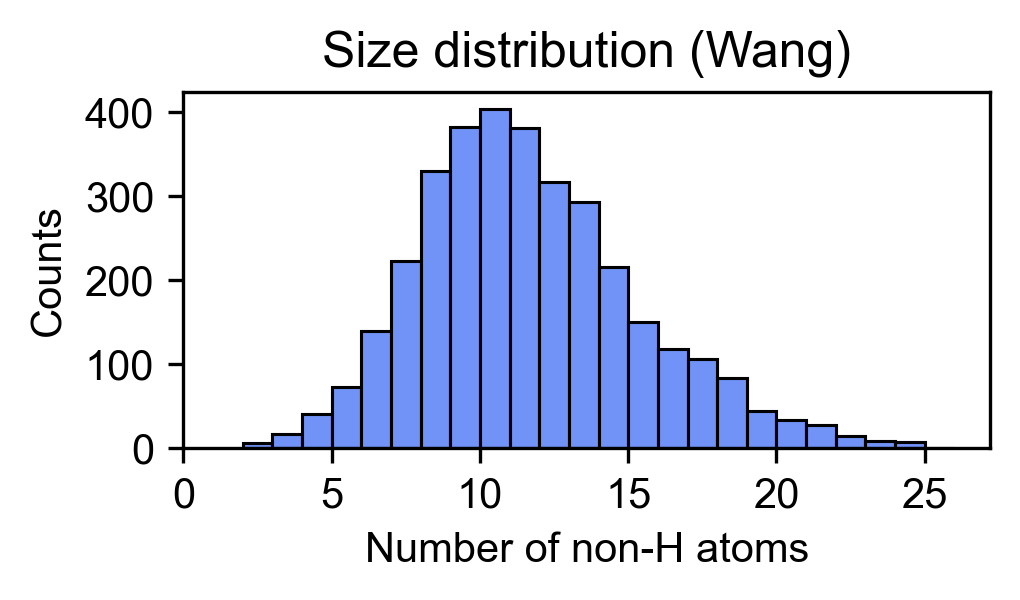

In [9]:
plot_size_dist(data, dataset)

# See which atoms are present

In [10]:
atomnums = calc_max_for_atoms(data['atomnums'])

Max Carbon atoms:  15
Max Nitrogen atoms:  3
Max Oxygen atoms:  12
Max Sulfur atoms:  1
Max Chlorine atoms:  4
Max Bromine atoms:  2
Atoms present: [ 6  7  8 16 17 35]


In [11]:
print_atom_counts(atomnums)

Carbon 22888
Nitrogen 1153
Oxygen 13835
Sulfur 15
Chlorine 207
Bromine 14


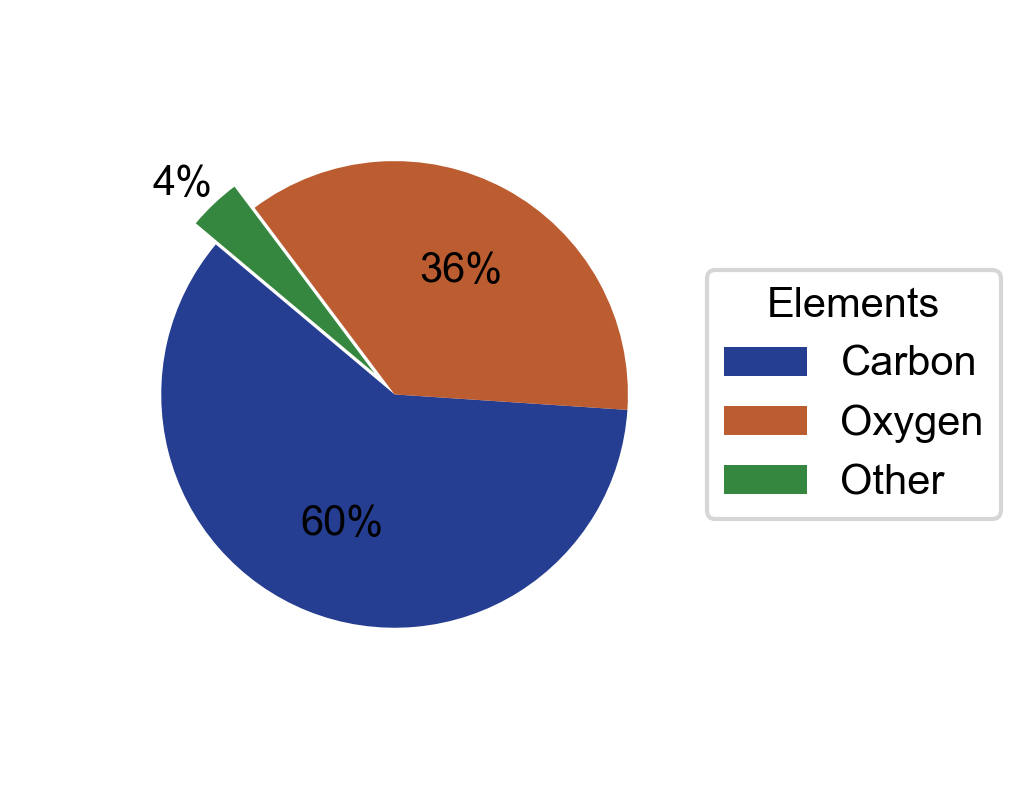

In [12]:
plot_wang_piegraph(no_4=False)

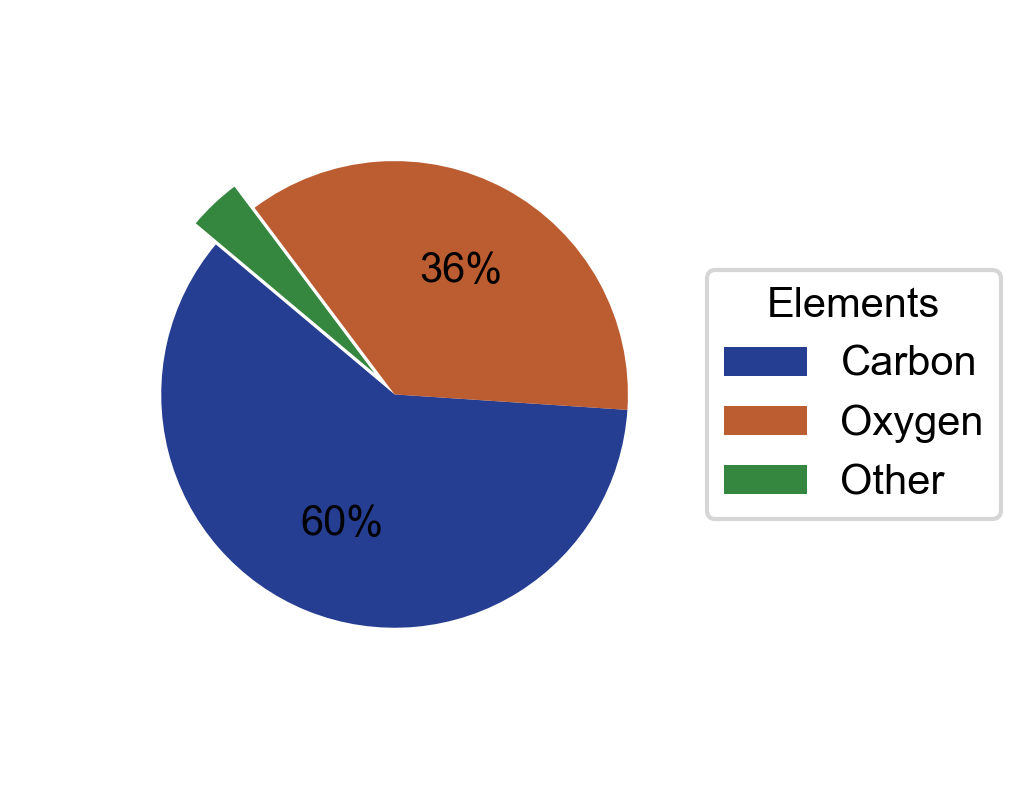

In [13]:
plot_wang_piegraph(no_4=True)

In [14]:
plt.close()

# Fragment statistics

In [15]:
data_sum, pairs, fragments, counts = fragment_stats(data)

('carbonyl', 3039)
('hydroxyl (alkyl)', 2210)
('ketone', 2006)
('non-aromatic ring', 1115)
('aldehyde', 1033)
('hydroperoxide', 928)
('nitrate', 711)
('ester', 364)


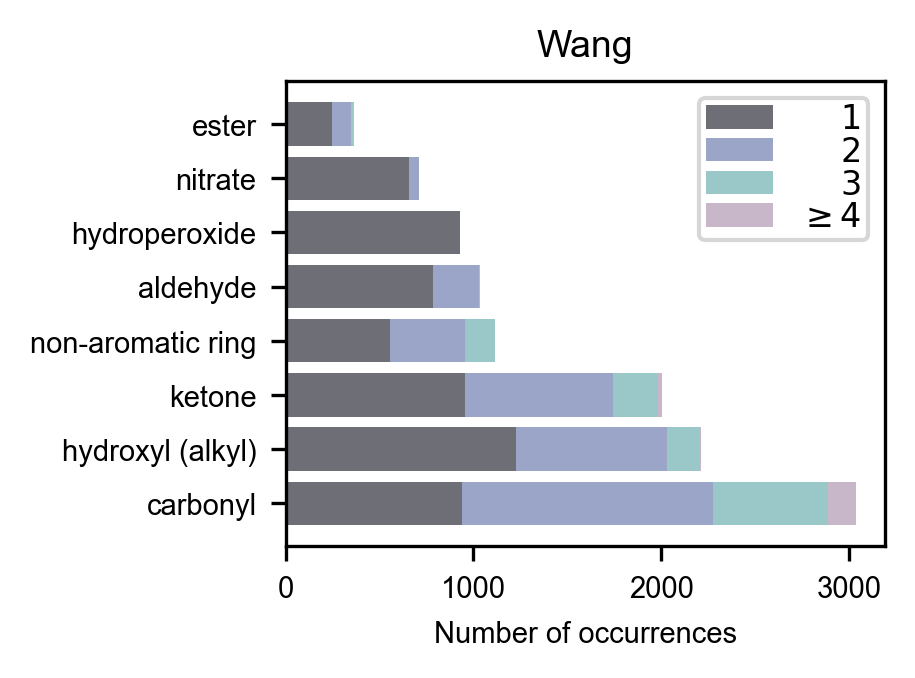

In [16]:
plot_fragments(data_sum, 'Wang')

# GeckoQ

In [17]:
dataset = 'GeckoQ'
filepath = f'../data/{dataset}/'
filename = 'descriptors/ATMO_DECIMAL_v4.txt'
data = load_data(filepath, filename, sep=' ', header = None)
data_smiles = np.loadtxt(f'{filepath}/smiles.txt', dtype=str, delimiter='~')
atmo_labels = np.loadtxt(f'{filepath}/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', dtype=str, delimiter='~')
atmo_labels = atmo_labels[166:]
data.columns = atmo_labels
data['compound'] = data_smiles
data.columns

Index(['amine, primary', 'amine, secondary', 'amine, tertiary', 'alkane CH',
       'alkene CH', 'aromatic CH', 'carbonyl', 'hydroxyl (alkyl)',
       'carboxylic acid', 'ester, all', 'ether', 'peroxide', 'nitro',
       'aromatic hydroxyl', 'hydroperoxide', 'amide', 'nitrate',
       'organosulfate', 'carbonylperoxynitrate', 'ketone', 'aldehyde',
       'amide, primary', 'amide, secondary', 'amide, tertiary',
       'carbonylperoxyacid', 'peroxy nitrate', 'ether, aromatic',
       'ether (alicyclic)', 'amine, aromatic', 'nitroester',
       'C=C-C=O in non-aromatic ring', 'C=C (non-aromatic)', 'nC-OHside-a',
       'aromatic ring', 'non-aromatic ring', 'nitrophenol', 'carbon number',
       'oxygen number', 'compound'],
      dtype='object')

In [18]:
data['atomnums'] = toAtomNum(data['compound'])
data.head(2)

,"amine, primary","amine, secondary","amine, tertiary",alkane CH,alkene CH,aromatic CH,carbonyl,hydroxyl (alkyl),carboxylic acid,"ester, all",...,C=C-C=O in non-aromatic ring,C=C (non-aromatic),nC-OHside-a,aromatic ring,non-aromatic ring,nitrophenol,carbon number,oxygen number,compound,atomnums
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,1,C(=O),"[6, 8]"
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,3,C(=O)(N(=O)(=O)),"[6, 8, 7, 8, 8]"


In [19]:
compare_prediction_heuristics(filepath, ['log_p_sat'],
                'geckoQ_processed_finalSG_props_298_uncorrected_231123.csv')

SIMPOL:  2.300181766009167
**************************
Mean prediction heuristics
**************************
KRR log_p_sat (shuffled targets): 1.6968746188925727
mean log_p_sat:  1.7216770403424972


In [20]:
atomnums = calc_max_for_atoms(data['atomnums'])

Max Carbon atoms:  10
Max Nitrogen atoms:  2
Max Oxygen atoms:  17
Atoms present: [6 7 8]


max atom count: 26
mean atom count: 17.85520118848184


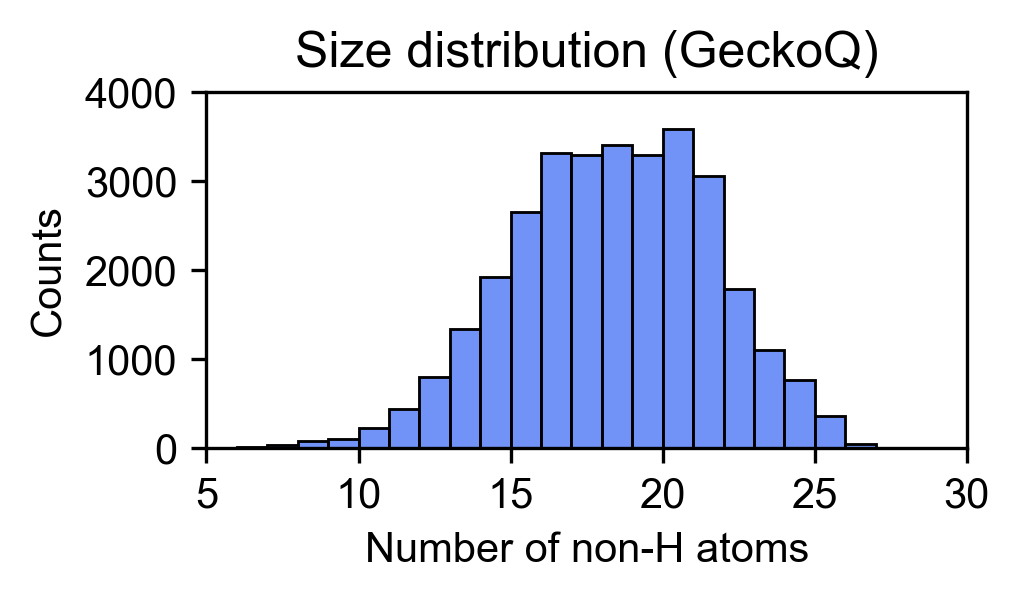

In [21]:
plot_geckoq_size_dist(data)

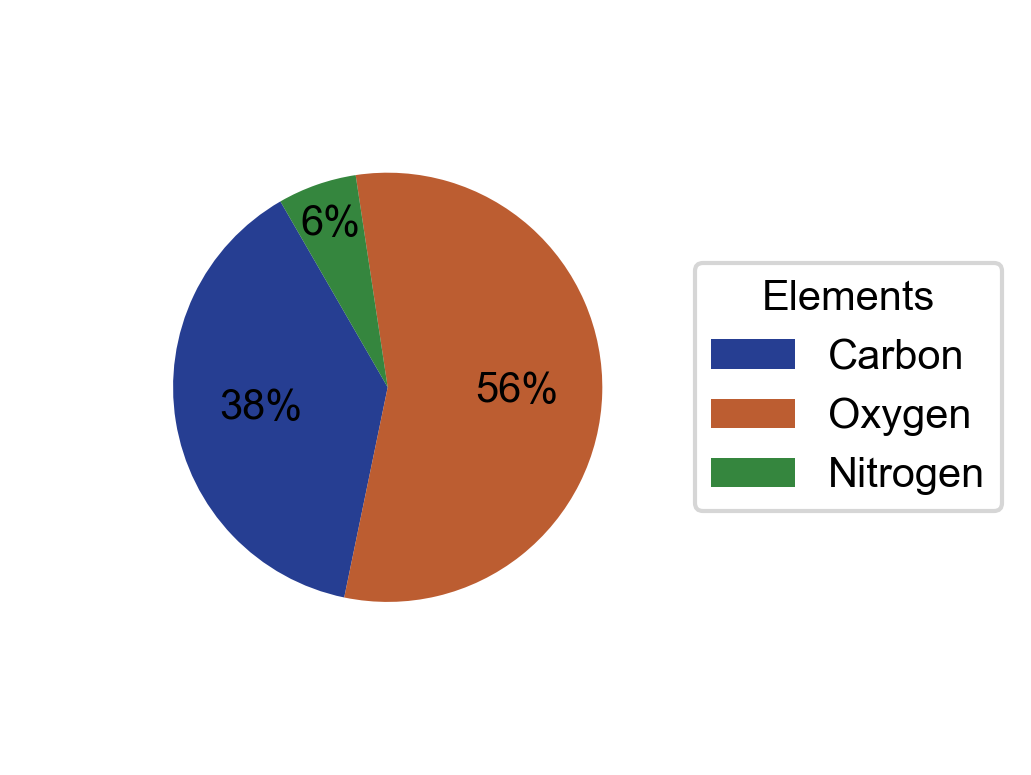

In [22]:
plot_geckoq_piegraph()

In [23]:
print_atom_counts(atomnums)

Carbon 217026
Nitrogen 33599
Oxygen 314260


# Fragment statistics

In [24]:
data_sum, pairs, fragments, counts = fragment_stats(data)

('carbonyl', 42651)
('ketone', 26205)
('hydroxyl (alkyl)', 26044)
('hydroperoxide', 24459)
('nitrate', 21041)
('non-aromatic ring', 16502)
('aldehyde', 16446)
('carboxylic acid', 10921)


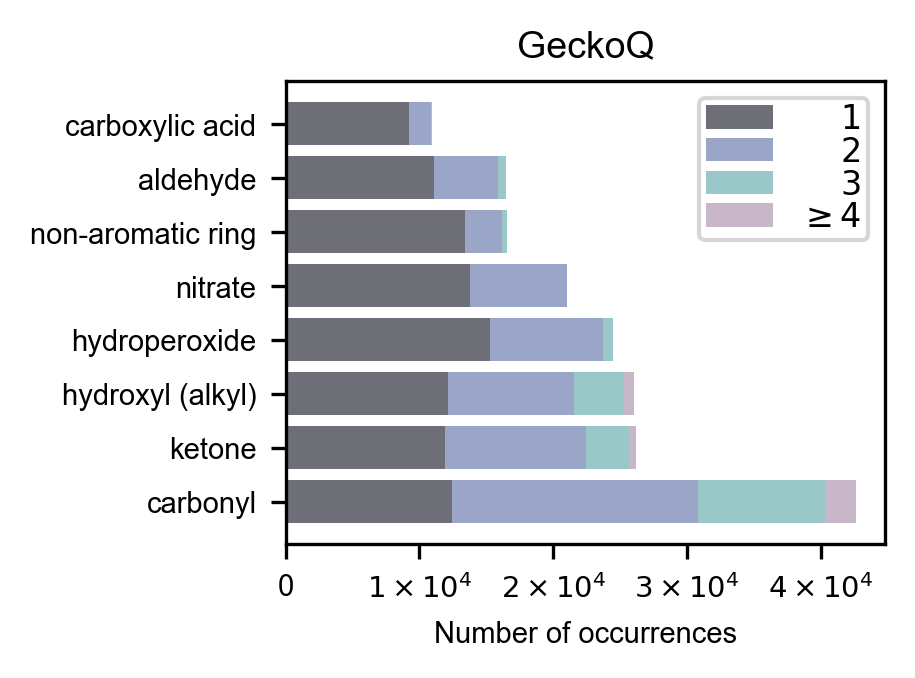

In [25]:
plot_fragments(data_sum, 'GeckoQ')

# Li 

In [26]:
dataset = 'Li'
filepath = f'../data/{dataset}/'
filename = 'descriptors/ATMO_DECIMAL_v4.txt'
data = load_data(filepath, filename, sep=' ', header = None)
data_smiles = np.loadtxt(f'{filepath}/smiles.txt', dtype=str, delimiter='~', comments='´')
atmo_labels = np.loadtxt(f'{filepath}/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', dtype=str, delimiter='~')
atmo_labels = atmo_labels[166:]
data.columns = atmo_labels
data['compound'] = data_smiles
data.columns

Index(['amine, primary', 'amine, secondary', 'amine, tertiary', 'alkane CH',
       'alkene CH', 'aromatic CH', 'carbonyl', 'hydroxyl (alkyl)',
       'carboxylic acid', 'ester, all', 'ether', 'peroxide', 'nitro',
       'aromatic hydroxyl', 'hydroperoxide', 'amide', 'nitrate',
       'organosulfate', 'carbonylperoxynitrate', 'ketone', 'aldehyde',
       'amide, primary', 'amide, secondary', 'amide, tertiary',
       'carbonylperoxyacid', 'peroxy nitrate', 'ether, aromatic',
       'ether (alicyclic)', 'amine, aromatic', 'nitroester',
       'C=C-C=O in non-aromatic ring', 'C=C (non-aromatic)', 'nC-OHside-a',
       'aromatic ring', 'non-aromatic ring', 'nitrophenol', 'carbon number',
       'oxygen number', 'compound'],
      dtype='object')

In [27]:
data['atomnums'] = toAtomNum(data['compound'])
data.head(2)

,"amine, primary","amine, secondary","amine, tertiary",alkane CH,alkene CH,aromatic CH,carbonyl,hydroxyl (alkyl),carboxylic acid,"ester, all",...,C=C-C=O in non-aromatic ring,C=C (non-aromatic),nC-OHside-a,aromatic ring,non-aromatic ring,nitrophenol,carbon number,oxygen number,compound,atomnums
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,1,C=O,"[6, 8]"
1,0,0,0,4,0,0,0,1,1,0,...,0,0,0,0,0,0,3,3,CC(O)C(O)=O,"[6, 6, 8, 6, 8, 8]"


max atom count: 51
mean atom count: 13.230595667870036


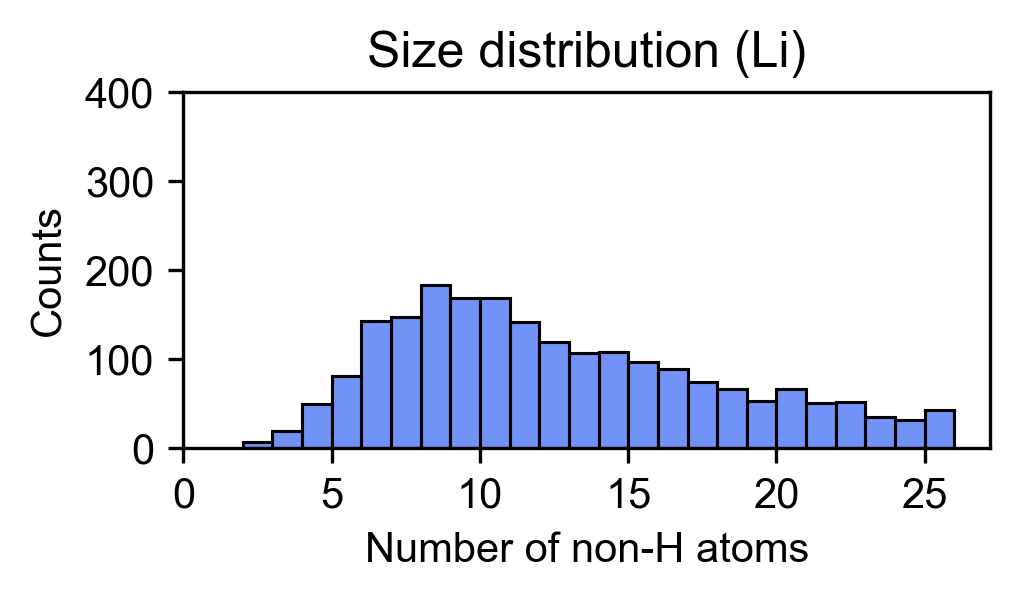

In [28]:
plot_size_dist(data, dataset)

In [29]:
atomnums = calc_max_for_atoms(data['atomnums'])

Max Hydrogen atoms:  1
Max Carbon atoms:  40
Max Nitrogen atoms:  10
Max Oxygen atoms:  23
Max Sodium atoms:  2
Max Sulfur atoms:  7
Max Chlorine atoms:  1
Atoms present: [ 1  6  7  8 11 16 17]


In [30]:
print_atom_counts(atomnums)

Hydrogen 6
Carbon 22409
Nitrogen 804
Oxygen 4862
Sodium 3
Sulfur 1228
Chlorine 7


In [31]:
data_sum, pairs, fragments, counts = fragment_stats(data)

('aromatic ring', 1665)
('non-aromatic ring', 600)
('ester', 470)
('hydroxyl (alkyl)', 361)
('carboxylic acid', 282)
('carbonyl', 274)
('ketone', 229)
('nC-OHside-a', 196)


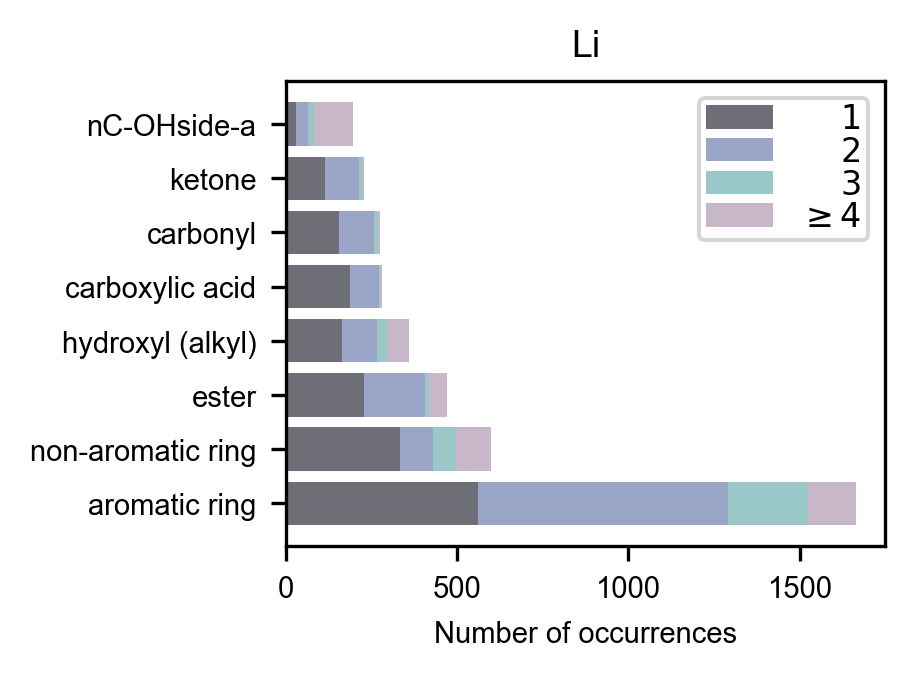

In [32]:
plot_fragments(data_sum, 'Li')

# Ferraz-Caetano

In [33]:
dataset = 'Ferraz-Caetano'
filepath = f'../data/{dataset}/'
filename = 'descriptors/ATMO_DECIMAL_v4.txt'
data = load_data(filepath, filename, sep=' ', header = None)
data_smiles = np.loadtxt(f'{filepath}/smiles.txt', dtype=str, delimiter='~')
atmo_labels = np.loadtxt(f'{filepath}/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', dtype=str, delimiter='~')
atmo_labels = atmo_labels[166:]
data.columns = atmo_labels
data['compound'] = data_smiles
data.columns

Index(['amine, primary', 'amine, secondary', 'amine, tertiary', 'alkane CH',
       'alkene CH', 'aromatic CH', 'carbonyl', 'hydroxyl (alkyl)',
       'carboxylic acid', 'ester, all', 'ether', 'peroxide', 'nitro',
       'aromatic hydroxyl', 'hydroperoxide', 'amide', 'nitrate',
       'organosulfate', 'carbonylperoxynitrate', 'ketone', 'aldehyde',
       'amide, primary', 'amide, secondary', 'amide, tertiary',
       'carbonylperoxyacid', 'peroxy nitrate', 'ether, aromatic',
       'ether (alicyclic)', 'amine, aromatic', 'nitroester',
       'C=C-C=O in non-aromatic ring', 'C=C (non-aromatic)', 'nC-OHside-a',
       'aromatic ring', 'non-aromatic ring', 'nitrophenol', 'carbon number',
       'oxygen number', 'compound'],
      dtype='object')

In [34]:
data['atomnums'] = toAtomNum(data['compound'])
data.head(3)


,"amine, primary","amine, secondary","amine, tertiary",alkane CH,alkene CH,aromatic CH,carbonyl,hydroxyl (alkyl),carboxylic acid,"ester, all",...,C=C-C=O in non-aromatic ring,C=C (non-aromatic),nC-OHside-a,aromatic ring,non-aromatic ring,nitrophenol,carbon number,oxygen number,compound,atomnums
0,0,0,0,17,3,0,0,0,0,0,...,0,1,0,0,0,0,10,0,CCCCCCCCC=C,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6]"
1,0,0,0,20,0,0,0,0,0,0,...,0,0,0,0,0,0,9,0,CCC(C)CC(C)(C)C,"[6, 6, 6, 6, 6, 6, 6, 6, 6]"
2,0,0,0,20,0,0,0,0,0,0,...,0,0,0,0,0,0,9,0,CCCCCCCCC,"[6, 6, 6, 6, 6, 6, 6, 6, 6]"


max atom count: 82
mean atom count: 11.182572614107883


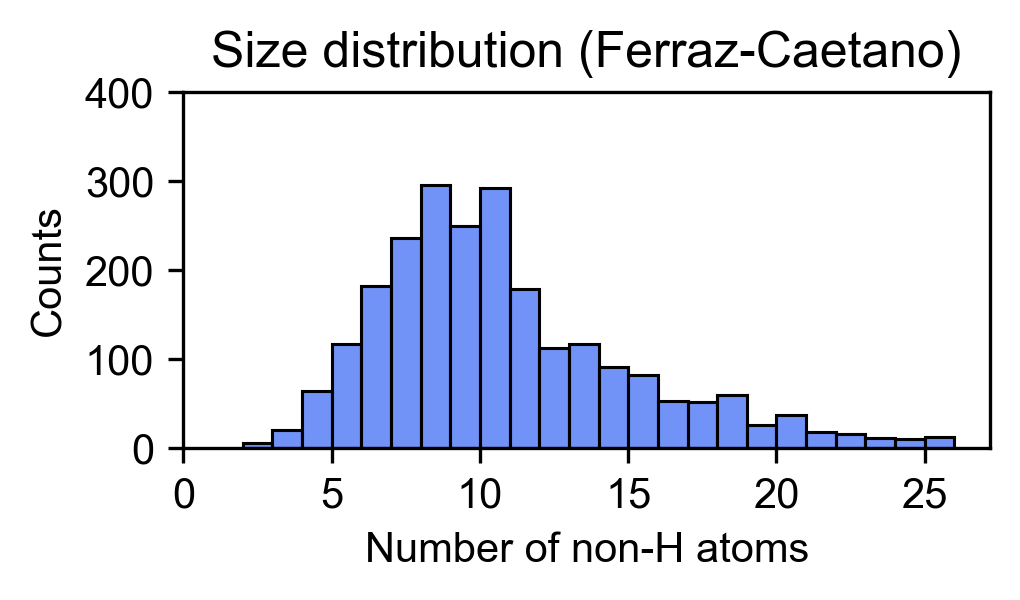

In [35]:

plot_size_dist(data, dataset)

In [36]:
atomnums = calc_max_for_atoms(data['atomnums'])

Max Carbon atoms:  82
Max Nitrogen atoms:  5
Max Oxygen atoms:  9
Max Fluorine atoms:  50
Max Phosphorus atoms:  2
Max Sulfur atoms:  3
Max Chlorine atoms:  7
Max Bromine atoms:  3
Max Iodine atoms:  2
Atoms present: [ 6  7  8  9 15 16 17 35 53]


In [37]:

print_atom_counts(atomnums)


Carbon 22430
Nitrogen 563
Oxygen 2139
Fluorine 1105
Phosphorus 33
Sulfur 176
Chlorine 401
Bromine 66
Iodine 37


In [38]:
data_sum, pairs, fragments, counts = fragment_stats(data)

('aromatic ring', 869)
('non-aromatic ring', 561)
('ester', 412)
('hydroxyl (alkyl)', 262)
('carbonyl', 186)
('ether', 185)
('nC-OHside-a', 113)
('ketone', 102)


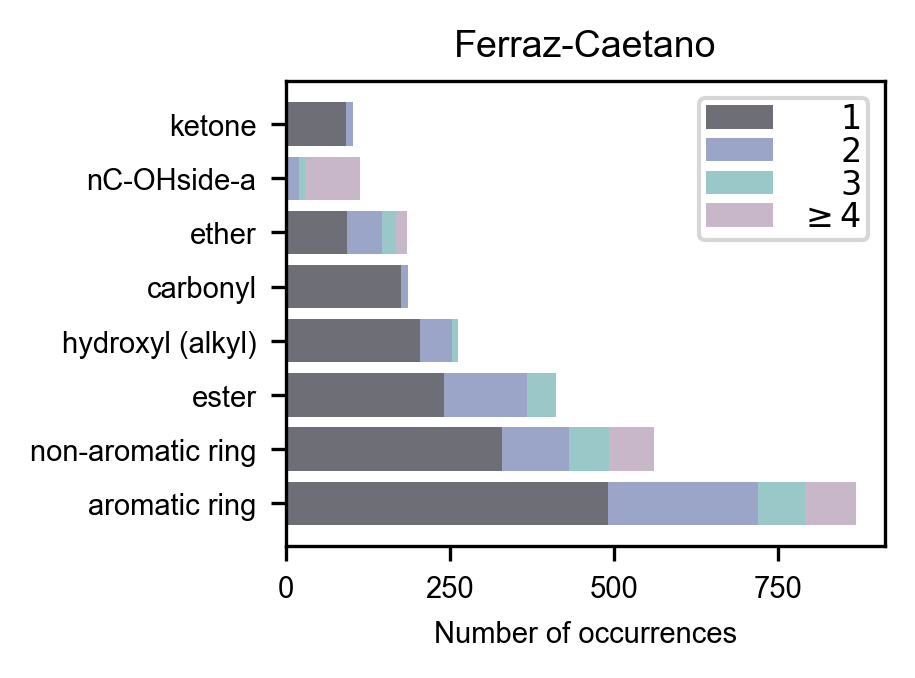

In [39]:
plot_fragments(data_sum, 'Ferraz-Caetano')

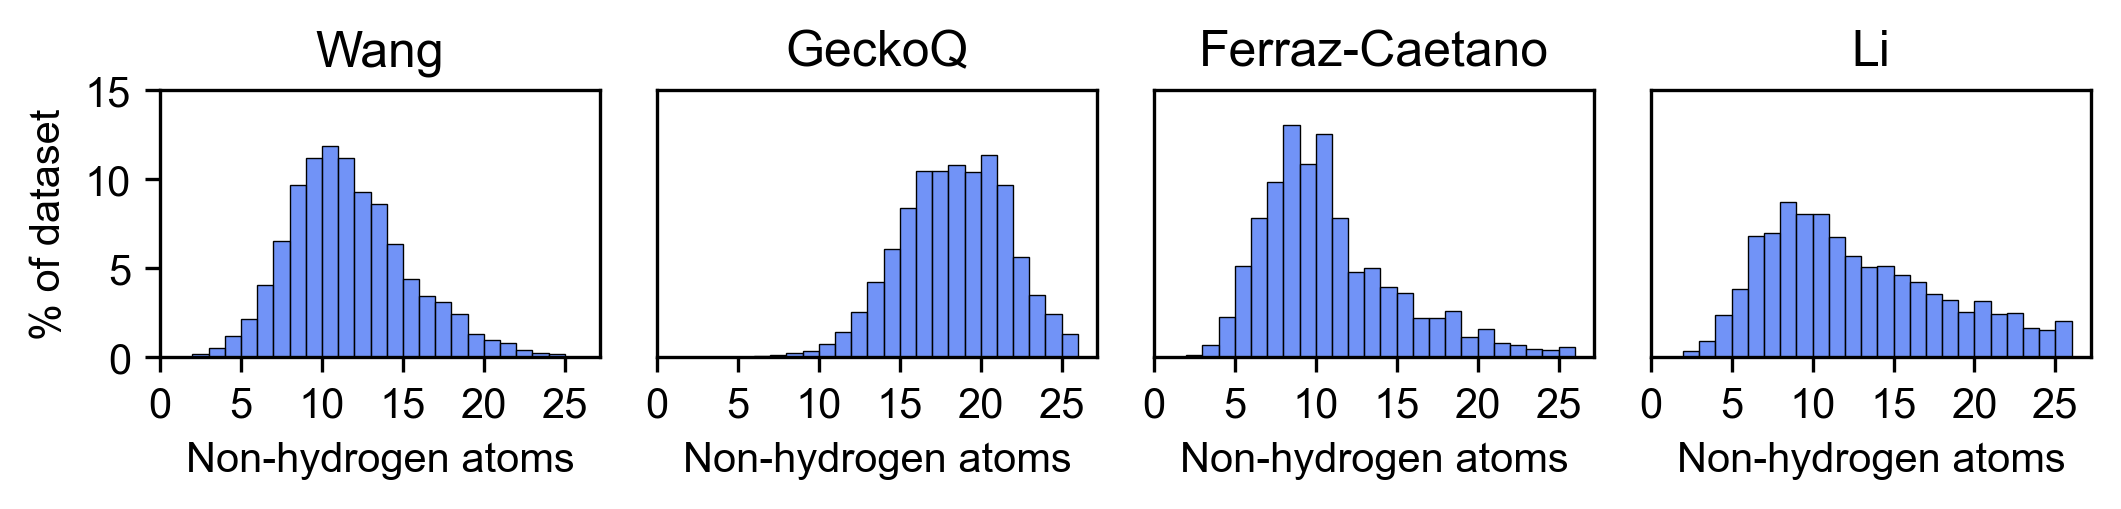

In [40]:
fs = 10
plt.rcParams.update({'font.size': fs})
datasets = ['Wang', 'GeckoQ', 'Ferraz-Caetano', 'Li']
filename = 'descriptors/ATMO_DECIMAL_v4.txt'
fig, axes = plt.subplots(1, 4, figsize=(7.17, 1.8), dpi=300)  # 1 row, 4 columns
for idx, dataset in enumerate(datasets):
    filepath = f'../data/{dataset}/'
    data = load_data(filepath, filename, sep=' ', header = None)
    data_smiles = np.loadtxt(f'{filepath}/smiles.txt', dtype=str, delimiter='~', comments='´')
    atmo_labels = np.loadtxt(f'{filepath}/descriptors/ATMOMACCS_DECIMAL_v4_feats.txt', dtype=str, delimiter='~')
    atmo_labels = atmo_labels[166:]
    data.columns = atmo_labels
    data['compound'] = data_smiles
    data['atomnums'] = toAtomNum(data['compound'])
    num_atoms = data['atomnums'].apply(len).values
    bin_edges = np.linspace(2,26,num=25)
    #plotting code
    ax = axes[idx]
    sns.histplot(num_atoms, bins=bin_edges, color='#426ff5', ax=ax, stat='percent')
    ax.set_xticks(np.linspace(0, 25, num=6))
    ax.set_title(f'{dataset}', fontsize = fs+2)
    ax.set_ylim([0, 15])
    if idx == 0:
        ax.set_ylabel('% of dataset' if idx == 0 else '')  # Only label y-axis on first plot
        ax.set_yticks(np.linspace(0, 15, num=4))
    else: 
        ax.set_ylabel(None)
        ax.set_yticks([])
    ax.set_xlabel('Non-hydrogen atoms')
plt.tight_layout()
plt.savefig(f'plots/size_dist_all_1x4.png', dpi = 300)
plt.show()

In [41]:

def plot_size_dist(data: pd.DataFrame, dataset: str):
    fs = 10
    plt.rcParams.update({'font.size': fs})
    num_atoms = data['atomnums'].apply(len).values
    print(f'max atom count: {max(num_atoms)}')
    print(f'mean atom count: {np.mean(num_atoms)}')
    bin_edges = np.linspace(2,26,num=25)
    plt.figure(figsize=(7/2, 5.25/2.5), dpi=300)
    sns.histplot(num_atoms, bins=bin_edges, color='#426ff5')
    plt.xticks(np.linspace(0,25, num = 6))
    plt.yticks(np.linspace(0,400, num=5))
    plt.title(f'Size distribution ({dataset})')
    plt.ylabel('Counts')
    plt.xlabel('Number of non-H atoms')
    plt.tight_layout()
    plt.savefig(f'plots/size_dist_{dataset}.png', dpi = 300)
    plt.show()